# **0. Import dan Note**

## 0.1. Penjelasan Library yang Digunakan

| No | Library | Fungsi |
|----|---------|--------|
| 1 | `pandas` | Membaca dan mengolah data dalam bentuk DataFrame |
| 2 | `matplotlib.pyplot` | Membuat visualisasi data seperti grafik |
| 3 | `seaborn` | Membuat plot statistik yang lebih menarik |
| 4 | `numpy` | Operasi numerik dan manipulasi array |
| 5 | `sklearn.model_selection.train_test_split` | Memisahkan data menjadi data latih dan data uji |
| 6 | `sklearn.preprocessing.LabelEncoder` | Mengubah label teks menjadi angka (encoding) |
| 7 | `sklearn.utils.class_weight` | Menghitung bobot kelas untuk menangani data tidak seimbang |
| 8 | `sklearn.metrics` | Menghitung akurasi, confusion matrix, dan classification report |
| 9 | `tensorflow.keras.preprocessing.text.Tokenizer` | Mengubah teks menjadi urutan angka (tokenization) |
| 10 | `tensorflow.keras.preprocessing.sequence.pad_sequences` | Menyamakan panjang sequence dengan padding |
| 11 | `tensorflow.keras.layers` | Layer-layer untuk membangun arsitektur LSTM |
| 12 | `tensorflow.keras.callbacks.EarlyStopping` | Menghentikan training lebih awal jika tidak ada peningkatan |
| 13 | `optuna` | Framework untuk hyperparameter tuning otomatis |

## 0.2. Arsitektur Model Deep Learning

| No | Layer | Keterangan |
|----|-------|-------------|
| 1 | `Input` | Layer input dengan shape (max_len=100) |
| 2 | `Embedding` | Mengubah token menjadi vektor 128 dimensi |
| 3 | `SpatialDropout1D` | Dropout khusus untuk data sequence (rate=0.3) |
| 4 | `Bidirectional LSTM` (Layer 1) | LSTM dua arah dengan units (64 atau 128) |
| 5 | `Bidirectional LSTM` (Layer 2) | LSTM dua arah dengan units (32 atau 64) |
| 6 | `GlobalAveragePooling1D` | Mengambil nilai rata-rata dari seluruh waktu |
| 7 | `GlobalMaxPooling1D` | Mengambil nilai maksimum dari seluruh waktu |
| 8 | `Concatenate` | Menggabungkan hasil average pool dan max pool |
| 9 | `Dense` (Layer 1) | Fully connected dengan units (32, 64, 96, atau 128) |
| 10 | `Dropout` | Dropout untuk mencegah overfitting |
| 11 | `Dense` (Layer 2 / Output) | Output layer dengan 3 neuron (negatif, netral, positif) dan aktivasi softmax |

## 0.3. Alur Pemodelan Deep Learning

| Step | Nama Step | Keterangan |
|------|-----------|-------------|
| 1 | Data Loading | Membaca dataset yang sudah dilabel dari file CSV |
| 2 | Label Encoding | Mengubah label teks (negative, neutral, positive) menjadi angka (0,1,2) |
| 3 | Train Test Split | Memisahkan data menjadi 80% training dan 20% testing dengan stratify |
| 3 | Class Weight Computation | Menghitung bobot kelas untuk menangani data tidak seimbang |
| 4 | Tokenization | Mengubah teks menjadi urutan angka dengan Tokenizer |
| 4 | Padding | Menyamakan panjang sequence menjadi 100 dengan padding post |
| 5 | Model Definition | Membangun arsitektur BiLSTM dengan pooling concatenation |
| 6 | Optuna Hyperparameter Tuning | Mencari parameter terbaik dengan 10 trial |
| 7 | Final Model Training | Melatih model dengan parameter terbaik |
| 8 | Evaluation | Evaluasi model dengan confusion matrix dan classification report |

## 0.4. Parameter yang Dioptimasi dengan Optuna

| No | Parameter | Rentang Nilai | Keterangan |
|----|-----------|---------------|-------------|
| 1 | `lstm_units1` | 64, 128 | Jumlah unit pada LSTM layer pertama |
| 2 | `lstm_units2` | 32, 64 | Jumlah unit pada LSTM layer kedua |
| 3 | `dropout_rate` | 0.2 - 0.5 | Tingkat dropout untuk regularisasi |
| 4 | `dense_units` | 32, 64, 96, 128 | Jumlah unit pada dense layer |
| 5 | `learning_rate` | 1e-4 - 1e-3 (log) | Learning rate untuk optimizer Adam |
| 6 | `batch_size` | 16, 32 | Ukuran batch untuk training |

## 0.5. Konfigurasi Training

| Parameter | Nilai | Keterangan |
|-----------|-------|-------------|
| `max_len` | 100 | Panjang maksimum setiap sequence |
| `num_words` | 5000 | Jumlah kata terbanyak yang digunakan |
| `embedding_dim` | 128 | Dimensi vektor embedding |
| `spatial_dropout_rate` | 0.3 | Dropout setelah embedding layer |
| `epochs` | 10 | Maksimum epoch training |
| `patience` | 2 | Epoch tunggu untuk early stopping |
| `class_weight` | Balanced | Bobot kelas dihitung otomatis |
| `validation_split` | 0.2 (dari X_test) | Data validasi terpisah |

## 0.6. Arsitektur Model dalam Bentuk Tabel

| Layer (type) | Output Shape | Param |
|--------------|--------------|-------|
| input_layer (InputLayer) | (None, 100) | 0 |
| embedding (Embedding) | (None, 100, 128) | vocab_size × 128 |
| spatial_dropout1d (SpatialDropout1D) | (None, 100, 128) | 0 |
| bidirectional (Bidirectional) | (None, 100, lstm_units1×2) | bervariasi |
| bidirectional_1 (Bidirectional) | (None, 100, lstm_units2×2) | bervariasi |
| global_average_pooling1d (GlobalAveragePooling1D) | (None, lstm_units2×2) | 0 |
| global_max_pooling1d (GlobalMaxPooling1D) | (None, lstm_units2×2) | 0 |
| concatenate (Concatenate) | (None, lstm_units2×4) | 0 |
| dense (Dense) | (None, dense_units) | bervariasi |
| dropout (Dropout) | (None, dense_units) | 0 |
| dense_1 (Dense) | (None, 3) | bervariasi |

## 0.7. Proses Optuna Hyperparameter Tuning

| Step | Keterangan |
|------|-------------|
| 1 | Optuna membuat 10 trial (percobaan) |
| 2 | Setiap trial memilih nilai parameter secara acak dari rentang yang ditentukan |
| 3 | Model dibangun dengan parameter tersebut |
| 4 | Model dilatih selama maksimal 10 epoch dengan early stopping |
| 5 | Akurasi pada data validasi dicatat |
| 6 | Trial dengan akurasi tertinggi dipilih sebagai best_params |
| 7 | Best parameters digunakan untuk training final model |

## 0.8. Metrik Evaluasi yang Digunakan

| Metrik | Fungsi |
|--------|--------|
| **Accuracy** | Persentase prediksi yang benar dari seluruh data |
| **Confusion Matrix** | Matriks yang menunjukkan jumlah prediksi benar dan salah per kelas |
| **Precision** | Proporsi prediksi positif yang benar |
| **Recall** | Proporsi data positif yang terdeteksi dengan benar |
| **F1-Score** | Rata-rata harmonis dari precision dan recall |


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate, SpatialDropout1D, Input, Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import optuna

# **1. Data Loading**

In [9]:
df = pd.read_csv('labeled_dataset.csv')
df.dropna(inplace=True)

df.head(10)

,comment,score,sentiment
0,wah yang belum menyaksikan trauma korea tonton...,0,neutral
1,oohh aku baru tau ternyata ada vaksin buat tyfus,0,neutral
2,tidak ada yang seru dokkk manusia berdarah itu,-1,negative
3,dok itu seperti begini loh woi dok di indonesia,-1,negative
4,pingin dengar cerita iyak meski takut lanjut d...,0,neutral
5,masih bisa cerita cerita sambil ketawa,1,positive
6,lah sama seperti gilbhas afgan raisa dan enzy,0,neutral
7,membuat dokk,1,positive
8,apa guys yang dimention sama dari,-1,negative
9,baru berani menyaksikan ini menyesal euy pegel...,1,positive


# **2. Label Encoding**

In [10]:
label_encoder = LabelEncoder()

comments = df['comment'].astype(str).values
labels = df['sentiment'].values

encoded_labels = label_encoder.fit_transform(labels)

# **3. Train Test Split dan Class Weight Computation**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(comments, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels)

weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(weights))

# **4. Tokenization dan Padding**

In [12]:
max_len = 100
num_words = 5000

tokenizer = Tokenizer(num_words=num_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

vocab_size = len(tokenizer.word_index) + 1

# **5. Model Building**

In [13]:
def build_enhanced_model(vocab_size, max_len, params):
    input_layer = Input(shape=(max_len,))
    
    x = Embedding(input_dim=vocab_size, output_dim=128)(input_layer)
    x = SpatialDropout1D(0.3)(x) 
    
    x = Bidirectional(LSTM(params['lstm_units1'], return_sequences=True))(x)
    x = Bidirectional(LSTM(params['lstm_units2'], return_sequences=True))(x)
    
    avg_pool = GlobalAveragePooling1D()(x)
    max_pool = GlobalMaxPooling1D()(x)
    
    conc = Concatenate()([avg_pool, max_pool])
    
    x = Dense(params['dense_units'], activation='relu')(conc)
    x = Dropout(params['dropout_rate'])(x)
    output = Dense(3, activation='softmax')(x)
    
    model = tf.keras.Model(inputs=input_layer, outputs=output)
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

# **6. Hyperparameter Tuning**

In [14]:
def objective(trial):
    params = {
        'lstm_units1': trial.suggest_categorical('lstm_units1', [64, 128]),
        'lstm_units2': trial.suggest_categorical('lstm_units2', [32, 64]),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.2, 0.5),
        'dense_units': trial.suggest_int('dense_units', 32, 128, step=32),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [16, 32])
    }

    model = build_enhanced_model(vocab_size, max_len, params)
    
    early_stop = EarlyStopping(monitor='val_loss', patience=2)

    model.fit(
        X_train_padded, y_train,
        validation_data=(X_test_padded, y_test),
        epochs=10,
        batch_size=params['batch_size'],
        class_weight=class_weights_dict,
        callbacks=[early_stop],
        verbose=0
    )

    score = model.evaluate(X_test_padded, y_test, verbose=0)
    return score[1]

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=10)

print(f"Best Accuracy : {study.best_value:.4f}")
print(f"Best Params   : {study.best_params}")

[I 2026-04-18 11:05:55,095] A new study created in memory with name: no-name-b6511485-c07e-4423-bec4-c2679bac4646
[I 2026-04-18 11:09:19,924] Trial 0 finished with value: 0.9171171188354492 and parameters: {'lstm_units1': 64, 'lstm_units2': 64, 'dropout_rate': 0.42005693681352474, 'dense_units': 32, 'learning_rate': 0.00010121437193843252, 'batch_size': 16}. Best is trial 0 with value: 0.9171171188354492.
[I 2026-04-18 11:11:12,499] Trial 1 finished with value: 0.9198198318481445 and parameters: {'lstm_units1': 64, 'lstm_units2': 32, 'dropout_rate': 0.30412011726361715, 'dense_units': 96, 'learning_rate': 0.0002314989887504327, 'batch_size': 32}. Best is trial 1 with value: 0.9198198318481445.
[I 2026-04-18 11:14:12,717] Trial 2 finished with value: 0.9117116928100586 and parameters: {'lstm_units1': 128, 'lstm_units2': 32, 'dropout_rate': 0.31481273302820467, 'dense_units': 32, 'learning_rate': 0.0006486980125055962, 'batch_size': 16}. Best is trial 1 with value: 0.9198198318481445.
[I

Best Accuracy : 0.9320
Best Params   : {'lstm_units1': 64, 'lstm_units2': 64, 'dropout_rate': 0.252931990892277, 'dense_units': 128, 'learning_rate': 0.0002528651432225061, 'batch_size': 16}


# **7. Final Model Training**

In [19]:
best_params = study.best_params

final_model = build_enhanced_model(vocab_size=vocab_size, max_len=max_len, params=best_params)

optimizer = tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate'])
final_model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=2)

history_best = final_model.fit(
    X_train_padded, y_train,
    validation_data=(X_test_padded, y_test),
    epochs=10,
    batch_size=best_params['batch_size'],
    class_weight=class_weights_dict,
    callbacks=[early_stop],
    verbose=1
)

y_pred_probs = final_model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)

Epoch 1/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.5662 - loss: 0.8771 - val_accuracy: 0.7658 - val_loss: 0.5540
Epoch 2/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.8545 - loss: 0.4075 - val_accuracy: 0.8779 - val_loss: 0.3243
Epoch 3/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.9170 - loss: 0.2490 - val_accuracy: 0.9041 - val_loss: 0.2831
Epoch 4/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.9474 - loss: 0.1651 - val_accuracy: 0.9104 - val_loss: 0.2818
Epoch 5/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.9610 - loss: 0.1245 - val_accuracy: 0.8964 - val_loss: 0.3262
Epoch 6/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.9689 - loss: 0.0955 - val_accuracy: 0.9266 - val_loss: 0.2645
Epoch 7/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.9755 - loss: 0.0755 - val_accuracy: 0.9270 - val_loss: 0.2895
Epoch 8/10
555/555 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - accuracy: 0.9814 - loss: 0.0589 - 

# **8. Model Evaluation**

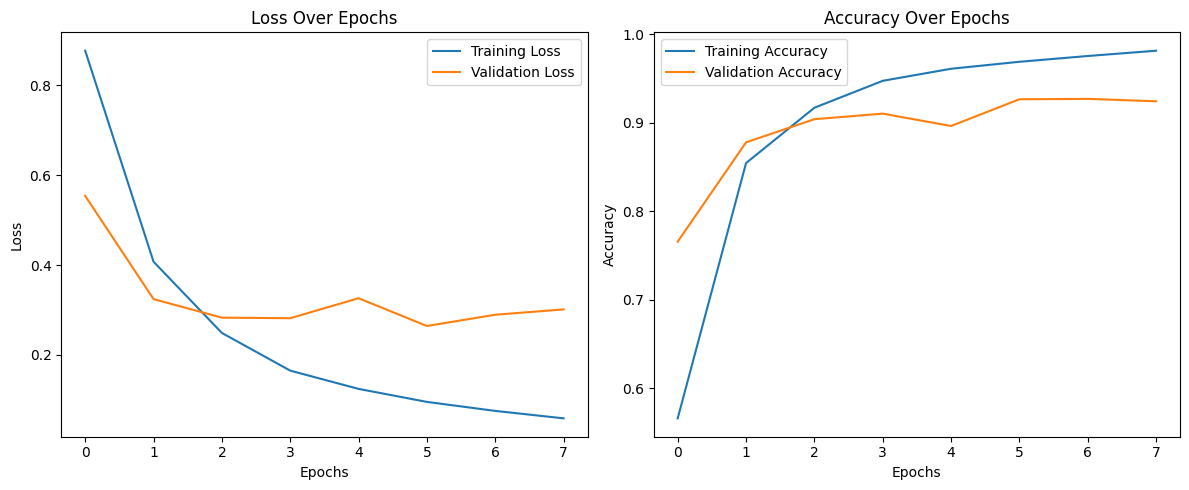

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_best.history['loss'], label='Training Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_best.history['accuracy'], label='Training Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

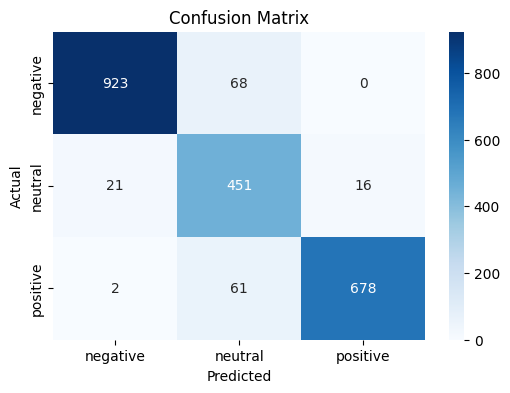

In [21]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy (Bi-LSTM): {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Test Accuracy (Bi-LSTM): 0.9243

Classification Report:
              precision    recall  f1-score   support

    negative       0.98      0.93      0.95       991
     neutral       0.78      0.92      0.84       488
    positive       0.98      0.91      0.94       741

    accuracy                           0.92      2220
   macro avg       0.91      0.92      0.91      2220
weighted avg       0.93      0.92      0.93      2220

